# Vector Fields - Nueral Net Approaches
## Sink + Vortex

## Defining a Good Data Set

Concentrated more in the middle for better termination.

In [1]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# 2. Define constants
x_start = y_start = 0
x_end = y_end = 10
quiver_step_size = 0.2
x_source = y_source = 5

robot_1_start = [2,2.2]
robot_2_offset = [0.3,0]
robot_3_offset = [0,0.3]

robot_step_size = 0.6

#2.  Defining Auxillary Functions.

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / dist 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / dist
    v = -v_theta * x_centre / dist

    # Add (-) the sink vector components
    u -=  x_centre / dist**2
    v -=  y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v,u)
    
    return mag, angle

#3. Defining Constants
num_iterations = 1000000 # 6,000,000

#4. Initializing Data
data = []

#5. Main
for i in range(num_iterations):
    # Generate random values for a, b, c, d, e, f, g, h
    a, b, c, d = np.random.uniform(0, 10, size=4)
    e, h = np.random.uniform(0.1, 1.5, size=2)
    f = g = 0
    
    x_source = a
    y_source = b
    
    pos1 = [c, d]
    pos2 = [c + e, d + f]
    pos3 = [c + g, d + h]
    
    u1, v1 = robot_readings(pos1[0], pos1[1], x_source, y_source)
    u2, v2 = robot_readings(pos2[0], pos2[1], x_source, y_source)
    u3, v3 = robot_readings(pos3[0], pos3[1], x_source, y_source)
    
    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)
    
    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x)
    distance = ((c-a)**2 + (d-b)**2)**0.5
    
       
    # Append the row of data to the list
    data.append([e, h, u1, v1, u2, v2, u3, v3, mag1, angle1, mag2, angle2, mag3, angle3, angle, distance, x_source, y_source])

for i in range(num_iterations):
    # Generate random values for a, b, c, d, e, f, g, h
    a, b, c, d = np.random.uniform(3, 7, size=4)
    e, h = np.random.uniform(0.1, 1.1, size=2)
    f = g = 0
    
    x_source = a
    y_source = b
    
    pos1 = [c, d]
    pos2 = [c + e, d + f]
    pos3 = [c + g, d + h]
    
    u1, v1 = robot_readings(pos1[0], pos1[1], x_source, y_source)
    u2, v2 = robot_readings(pos2[0], pos2[1], x_source, y_source)
    u3, v3 = robot_readings(pos3[0], pos3[1], x_source, y_source)
    
    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)
    
    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x)
    distance = ((c-a)**2 + (d-b)**2)**0.5
    
       
    # Append the row of data to the list
    data.append([e, h, u1, v1, u2, v2, u3, v3, mag1, angle1, mag2, angle2, mag3, angle3, angle, distance, x_source, y_source])

    
# Convert the list to a DataFrame
df = pd.DataFrame(data, columns=['e', 'h', 'u1', 'v1', 'u2', 'v2', 'u3', 'v3', 'mag1', 'angle1', 'mag2', 'angle2', 'mag3', 'angle3', 'angle', 'distance', 'x_source', 'y_source'])



# Nueral Net #1, finding X-Source and Y Source from the Above Data
This uses df1

In [2]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare the data
X = df[['e', 'h', 'u1', 'v1', 'u2', 'v2', 'u3', 'v3']].values
y = df[['distance']].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)

# Convert to PyTorch tensors and move to the device
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# Define the model
model = nn.Sequential(
    nn.Linear(8, 8),  # input layer to first hidden layer
    nn.LeakyReLU(),  # activation function
    nn.Linear(8, 8),  # 1 to 2
    nn.LeakyReLU(),  # activation function
    nn.Linear(8, 8),  # 1 to 2
    nn.LeakyReLU(),  # activation function
    nn.Linear(8, 8),  # 1 to 2
    nn.LeakyReLU(),  # activation function
    nn.Linear(8, 6),  # 2 to 3
    nn.LeakyReLU(),  # activation function
    nn.Linear(6, 4),  # 3 to 4
    nn.LeakyReLU(),  # activation function
    nn.Linear(4, 4),  # 3 to 4
    nn.LeakyReLU(),  # activation function
    nn.Linear(4, 2),  # 3 to 4
    nn.LeakyReLU(),  # activation function
    nn.Linear(2, 1), #  4 to output layer
)

model = model.to(device)
# Define a loss function and an optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.004)

# Train the model
epochs = 300     
for epoch in range(epochs):
    # Compute the model output and loss
    pred = model(X_train)
    loss = loss_fn(pred, y_train)

    # Perform backpropagation
    loss.backward()

    # Update the weights
    optimizer.step()

    # Reset the gradients
    optimizer.zero_grad()

    # Print the loss for this epoch
    if epoch%100 ==0: 
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

# Evaluate on the test data
model.eval() # switch the model to evaluation mode
with torch.no_grad():
    pred_test = model(X_test)
    test_loss = loss_fn(pred_test, y_test)
    print(f'Test Loss: {test_loss.item()}')


Epoch 1/300, Loss: 21.109804153442383
Epoch 101/300, Loss: 5.7654242515563965
Epoch 201/300, Loss: 2.9553353786468506
Test Loss: 0.47024187445640564


# Neural Net - Model 2

In [3]:
import torch
from torch import nn
from sklearn.model_selection import train_test_split

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Prepare the data
X = df[['e', 'h', 'u1', 'v1', 'u2', 'v2', 'u3', 'v3']].values
y = df[['distance']].values

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

# Convert to PyTorch tensors and move to the device
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# Define the model
model2 = nn.Sequential(
    nn.Linear(8, 8),  # input layer to first hidden layer
    nn.ReLU(),  # activation function
    nn.Linear(8, 4),  # 1 to 2
    nn.ELU(),  # activation function
    nn.Linear(4, 3),  # 1 to 2
    nn.LeakyReLU(),  # activation functio
    nn.Linear(3, 2),  # 1 to 2
    nn.Tanh(),  # activation function
    nn.Linear(2, 1),  # 3 to 4
)


model2 = model2.to(device)
# Define a loss function and an optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model2.parameters(), lr=0.0012)

# Train the model
epochs = 500     
for epoch in range(epochs):
    # Compute the model output and loss
    pred = model2(X_train)
    loss = loss_fn(pred, y_train)

    # Perform backpropagation
    loss.backward()

    # Update the weights
    optimizer.step()

    # Reset the gradients
    optimizer.zero_grad()

    # Print the loss for this epoch
    if epoch%100 ==0: 
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

# Evaluate on the test data
model2.eval() # switch the model to evaluation mode
with torch.no_grad():
    pred_test = model2(X_test)
    test_loss = loss_fn(pred_test, y_test)
    print(f'Test Loss: {test_loss.item()}')


Epoch 1/500, Loss: 26.74090576171875
Epoch 101/500, Loss: 22.757368087768555
Epoch 201/500, Loss: 17.010984420776367
Epoch 301/500, Loss: 12.926224708557129
Epoch 401/500, Loss: 10.865768432617188
Test Loss: 9.473054885864258


## The Main Algorithm  - Centre Finder Using Inference

[2, 2.5] [2.5, 2.5] [2, 3.0]


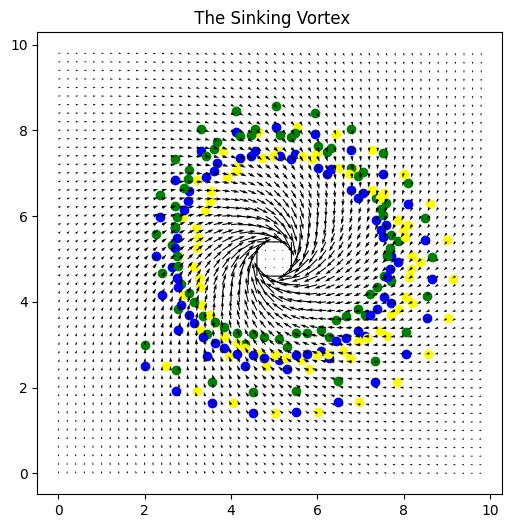

[7.529927035938988, 5.517902631200424] [8.029927035938988, 5.517902631200424] [7.529927035938988, 6.017902631200424]


In [7]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# 2. Define constants
x_start = y_start = 0
x_end = y_end = 10
quiver_step_size = 0.2
x_source = y_source = 5

robot_1_start = [2,2.5]
robot_2_offset = [0.5,0]
robot_3_offset = [0,0.5]

robot_step_size = 1
dist_to_centre = 0.8

# 3. Declare Functions

def run_model(angle, c, d, e, f, g, h, model):
    
    robot_1_start = [c, d]
    robot_2_offset = [e, f]
    robot_3_offset = [g, h]

    pos1 = robot_1_start
    pos2 = [(robot_1_start[0] + robot_2_offset[0]), (robot_1_start[1] + robot_2_offset[1])]
    pos3 = [(robot_1_start[0] + robot_3_offset[0]), (robot_1_start[1] + robot_3_offset[1])]

    [u1, v1] = robot_readings(pos1[0], pos1[1], x_source, y_source)
    [u2, v2] = robot_readings(pos2[0], pos2[1], x_source, y_source)
    [u3, v3] = robot_readings(pos3[0], pos3[1], x_source, y_source)

    [mag1, angle1] = composite_vector(u1, v1)
    [mag2, angle2] = composite_vector(u2, v2)
    [mag3, angle3] = composite_vector(u3, v3)

  
    new_data = torch.tensor([e, h, u1, v1, u2, v2, u3, v3]).float()
    new_data = new_data.unsqueeze(0)

    model.to('cpu')
    model.eval()

    with torch.no_grad():
        prediction = model(new_data)

    x_predicted = c + prediction.item() * np.cos(angle)
    y_predicted = d + prediction.item() * np.sin(angle)
    
    #print('C:', c, 'Distance', prediction.item(), 'angle:', angle)
    
    #print ('Predicted X:' , x_predicted, 'Predicted Y: ', y_predicted)

    return prediction.item(), x_predicted, y_predicted

def sinking_vortex(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source

    # Calculate the distance r from the center
    r = np.sqrt(x_centre**2 + y_centre**2)
    r[r<0.5] = 100

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / r 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    # Add (-) the sink vector components
    u -=  x_centre / r**2
    v -=  y_centre / r**2

    return u, v

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    
    # Calculate the magnitude based on distance from centre
    v_theta = 1 / dist 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / dist
    v = -v_theta * x_centre / dist

    # Add (-) the sink vector components
    u -=  x_centre / dist**2
    v -=  y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v2,u2)
    
    return mag, angle

def plot_robot_position(pos1,pos2,pos3):

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    
def update_robot_position_cir(pos1,pos2,pos3, angle, distance_pred, x_predicted, y_predicted, robot_step_size):
    
    # Calculate Angle Needed to move
    move_angle = np.arctan2(robot_step_size, distance_pred)
    new_angle = angle + move_angle + np.pi
    
    # Calculating new positions
    pos1[0] = x_predicted + distance_pred*np.cos(new_angle)
    pos1[1] = y_predicted + distance_pred*np.sin(new_angle)
    pos2[0] = pos1[0] + 0.5
    pos2[1] = pos1[1]
    pos3[0] = pos1[0]
    pos3[1] = pos1[1]+ 0.5
    
    return pos1, pos2, pos3

# 4. Initialize

# Initialize The Sinking Vortex Field
x = np.arange(x_start, x_end, quiver_step_size)
y = np.arange(y_start, y_end, quiver_step_size)
X, Y = np.meshgrid(x, y)
u, v = sinking_vortex(X, Y, x_source, y_source)

# Initialize the Robot's positions
pos1=robot_1_start
pos2=[(robot_1_start[0] + robot_2_offset[0]),(robot_1_start[1] + robot_2_offset[1])]
pos3=[(robot_1_start[0] + robot_3_offset[0]),(robot_1_start[1] + robot_3_offset[1])]

# Initialize output Plot
plt.figure(figsize=(6, 6))
plot_robot_position(pos1,pos2,pos3)
print(pos1, pos2, pos3)

# 5. Main

for _ in range(1,80):
    # Check Break Criteria

    # Find u,v, angle and magnitude at each Robot

    [u1, v1] = robot_readings(pos1[0],pos1[1], x_source,y_source)
    [u2, v2] = robot_readings(pos2[0],pos2[1], x_source,y_source)
    [u3, v3] = robot_readings(pos3[0],pos3[1], x_source,y_source)

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)



    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x)

    
    distance_pred, x_predicted, y_predicted = run_model(angle, pos1[0], pos1[1], pos2[0], pos2[1], pos3[0], pos3[1], model)



    #if distance_pred < 0.01:
    #    break     
    
    [pos1, pos2, pos3] = update_robot_position_cir(pos1,pos2,pos3,angle, distance_pred, x_predicted, y_predicted, robot_step_size)


    # Plot Robot Position
    plot_robot_position(pos1,pos2,pos3)

# 6. Plot Outcome


plt.quiver(x, y, u, v)
plt.title(' The Sinking Vortex')
#plot_extra_features(x, y, u, v, x_source, y_source)
plt.show()
print(pos1,pos2,pos3)


# The Main Algorithm  - Circumnavigator Using Inference

Predicted Distance:  1.7889968156814575 Angle:  0.6784687190942716
Predicted Distance:  1.7890559434890747 Angle:  0.6787145758668932
Predicted Distance:  1.7890576124191284 Angle:  -2.4276250333707603
Predicted Distance:  1.7890559434890747 Angle:  0.7199573176143976
Predicted Distance:  1.7890576124191284 Angle:  -2.398788970807526
Predicted Distance:  1.7890559434890747 Angle:  0.7467257340665634
Predicted Distance:  1.7890576124191284 Angle:  -2.381076422238551
Predicted Distance:  1.7890559434890747 Angle:  0.7628928591803569
Predicted Distance:  1.7890576124191284 Angle:  -2.3706141398448386
Predicted Distance:  1.7890559434890747 Angle:  0.7723738606883674
Predicted Distance:  1.7890576124191284 Angle:  -2.364527482676276
Predicted Distance:  1.7890559434890747 Angle:  0.7778751192865486
Predicted Distance:  1.7890576124191284 Angle:  -2.3610054097248074
Predicted Distance:  1.7890559434890747 Angle:  0.7810555570339458
Predicted Distance:  1.7890576124191284 Angle:  -2.35897107

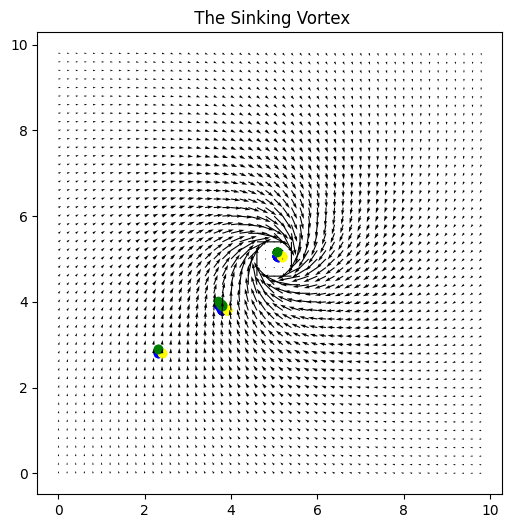

[5.066514160539437, 5.066410636378707] [5.166514160539436, 5.066410636378707] [5.066514160539437, 5.166410636378707]


In [11]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

# 2. Define constants
x_start = y_start = 0
x_end = y_end = 10
quiver_step_size = 0.2
x_source = y_source = 5

robot_1_start = [2.3,2.8]
robot_2_offset = [0.1,0]
robot_3_offset = [0,0.1]

robot_step_size = 0.6
dist_to_centre = 0.8

# 3. Declare Functions

def run_model(c, d, e, f, g, h, model):
    
    robot_1_start = [c, d]
    robot_2_offset = [e, f]
    robot_3_offset = [g, h]

    pos1 = robot_1_start
    pos2 = [(robot_1_start[0] + robot_2_offset[0]), (robot_1_start[1] + robot_2_offset[1])]
    pos3 = [(robot_1_start[0] + robot_3_offset[0]), (robot_1_start[1] + robot_3_offset[1])]

    [u1, v1] = robot_readings(pos1[0], pos1[1], x_source, y_source)
    [u2, v2] = robot_readings(pos2[0], pos2[1], x_source, y_source)
    [u3, v3] = robot_readings(pos3[0], pos3[1], x_source, y_source)

    [mag1, angle1] = composite_vector(u1, v1)
    [mag2, angle2] = composite_vector(u2, v2)
    [mag3, angle3] = composite_vector(u3, v3)

    slope_x = (mag2 - mag1) / robot_2_offset[0]
    slope_y = (mag3 - mag1) / robot_3_offset[1]
    angle = np.arctan2(slope_y, slope_x)
  
    new_data = torch.tensor([e, h, u1, v1, u2, v2, u3, v3]).float()
    new_data = new_data.unsqueeze(0)

    model.to('cpu')
    model.eval()

    with torch.no_grad():
        prediction = model(new_data)

    x_predicted = c + prediction.item() * np.cos(angle)
    y_predicted = d + prediction.item() * np.sin(angle)

    return prediction.item()

def sinking_vortex(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source

    # Calculate the distance r from the center
    r = np.sqrt(x_centre**2 + y_centre**2)
    r[r<0.5] = 100

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / r 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / r
    v = -v_theta * x_centre / r

    # Add (-) the sink vector components
    u -=  x_centre / r**2
    v -=  y_centre / r**2

    return u, v

def robot_readings(x, y, x_source, y_source):
    
    # Centring over sink
    x_centre = x - x_source
    y_centre = y - y_source
    
    # Calculate the distance r from the center
    dist = np.sqrt((x-x_source)**2 + (y-y_source)**2)
    

    # Calculate the magnitude based on distance from centre
    v_theta = 1 / dist 

    # Decompose Vector into u,v for vortex
    u = v_theta * y_centre / dist
    v = -v_theta * x_centre / dist

    # Add (-) the sink vector components
    u -=  x_centre / dist**2
    v -=  y_centre / dist**2
                   
    return u, v

def composite_vector(u,v):
    
    mag = np.sqrt(u**2 + v**2)
    angle = np.arctan2(v2,u2)
    
    return mag, angle

def plot_robot_position(pos1,pos2,pos3):

    plt.scatter(pos1[0],pos1[1], marker='o', color='blue')
    plt.scatter(pos2[0],pos2[1], marker='o', color = 'yellow')
    plt.scatter(pos3[0],pos3[1], marker='o', color = 'green')
    
    
def update_robot_position_nn(pos1,pos2,pos3, angle, distance_pred):
    
    pos1[0] += distance_pred*np.cos(angle)
    pos1[1] += distance_pred*np.sin(angle)
    pos2[0] += distance_pred*np.cos(angle)
    pos2[1] += distance_pred*np.sin(angle)
    pos3[0] += distance_pred*np.cos(angle)
    pos3[1] += distance_pred*np.sin(angle)
    
    return pos1, pos2, pos3

# 4. Initialize

# Initialize The Sinking Vortex Field
x = np.arange(x_start, x_end, quiver_step_size)
y = np.arange(y_start, y_end, quiver_step_size)
X, Y = np.meshgrid(x, y)
u, v = sinking_vortex(X, Y, x_source, y_source)

# Initialize the Robot's positions
pos1=robot_1_start
pos2=[(robot_1_start[0] + robot_2_offset[0]),(robot_1_start[1] + robot_2_offset[1])]
pos3=[(robot_1_start[0] + robot_3_offset[0]),(robot_1_start[1] + robot_3_offset[1])]

# Initialize output Plot
plt.figure(figsize=(6, 6))
plot_robot_position(pos1,pos2,pos3)

# 5. Main

for _ in range(1,25):
    # Check Break Criteria

    # Find u,v, angle and magnitude at each Robot

    [u1, v1] = robot_readings(pos1[0],pos1[1], x_source,y_source)
    [u2, v2] = robot_readings(pos2[0],pos2[1], x_source,y_source)
    [u3, v3] = robot_readings(pos3[0],pos3[1], x_source,y_source)

    [mag1, angle1] = composite_vector(u1,v1)
    [mag2, angle2] = composite_vector(u2,v2)
    [mag3, angle3] = composite_vector(u3,v3)

    # Plot Robot Position
    plot_robot_position(pos1,pos2,pos3)

    # Update Robot Position
    slope_x = (mag2 - mag1) / robot_2_offset[0] 
    slope_y = (mag3 - mag1) / robot_3_offset[1] 
    angle = np.arctan2(slope_y,slope_x)
    
    distance_pred = run_model(pos1[0], pos1[1], pos2[0], pos2[1], pos3[0], pos3[1], model2)
    
    if distance_pred < 0.3:
        break
        
    
    [pos1, pos2, pos3] = update_robot_position_nn(pos1,pos2,pos3,angle, distance_pred)
    print('Predicted Distance: ' ,distance_pred, 'Angle: ', angle)


# 6. Plot Outcome


plt.quiver(x, y, u, v)
plt.title(' The Sinking Vortex')
#plot_extra_features(x, y, u, v, x_source, y_source)
plt.show()
print(pos1,pos2,pos3)
